In [7]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pvlib
from susse.estimators.validation.metrics import StatisticalMetrics

In [2]:
# Coordinates for Soroti, Uganda
latitude = 1.7157
longitude = 33.6117
tz = 'Africa/Kampala'

start = '2021-01-01'
end = '2022-01-01'

# Ground data

In [3]:
Soroti_ground = pd.read_csv('Data/irradiation_measurements/ministry_energy_ug/cleaned/Soroti/Soroti_2021.csv')
Soroti_ground['Day'] = pd.to_datetime(Soroti_ground['Day'])
Soroti_ground = Soroti_ground.set_index('Day')
Soroti_ground.head()

,Temperature (C),Temperature (SAT) (C),Rain (mm),GHI_1 (kWh/m2/day),GHI_2 (kWh/m2/day),GHI_SAT (kWh/m2/day),GHI (1) vs (2) (%),GHI (1) vs (SAT) (%),DHI (1) (kWh/m2/day),DHI (SAT) (kWh/m2/day),DHI (1) vs (SAT) (%)
Day,,,,,,,,,,,
2021-01-01,20.31,24.67,8.4,3.10,3.11,2.53,-0.35,18.50,2.25,1.60,28.86
2021-01-02,22.86,25.09,0.0,6.03,6.05,6.83,-0.29,-13.14,1.50,1.90,-26.98
2021-01-03,24.08,25.08,0.0,6.54,6.58,6.86,-0.66,-4.88,1.73,1.87,-7.77
2021-01-04,24.65,25.67,0.0,6.57,6.61,6.64,-0.65,-1.01,2.30,2.07,10.15
2021-01-05,24.87,25.31,0.0,6.51,6.54,6.83,-0.60,-4.97,1.77,1.84,-3.67


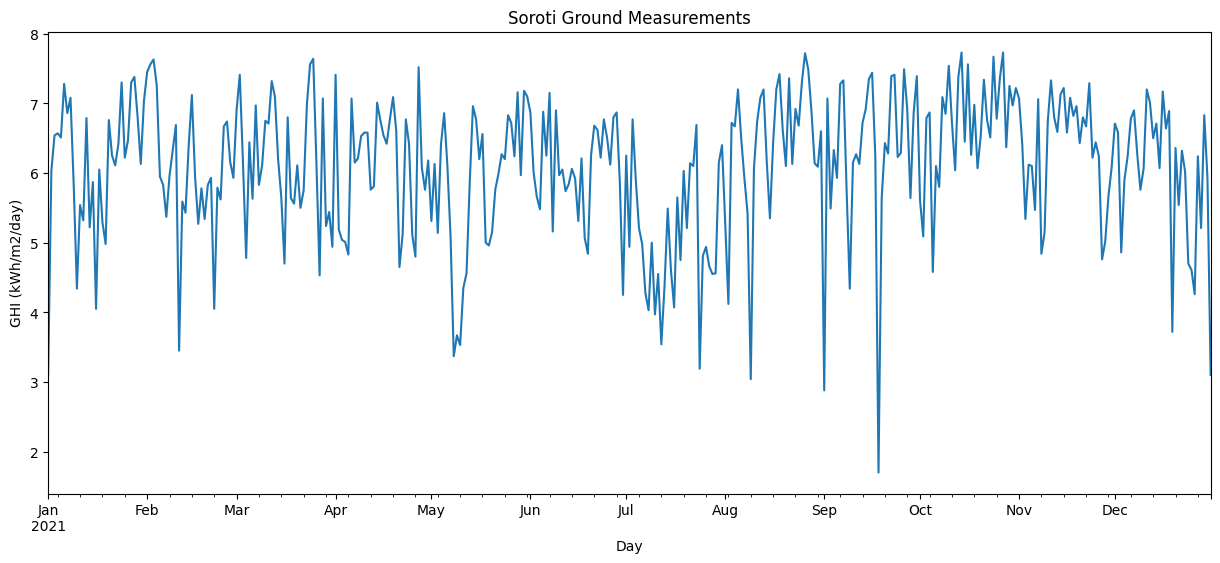

In [4]:
plt.figure(figsize=(15, 6))
ghi_ground = Soroti_ground['GHI_1 (kWh/m2/day)']
ghi_ground.plot()   
plt.ylabel('GHI (kWh/m2/day)')
plt.title('Soroti Ground Measurements')
plt.show()

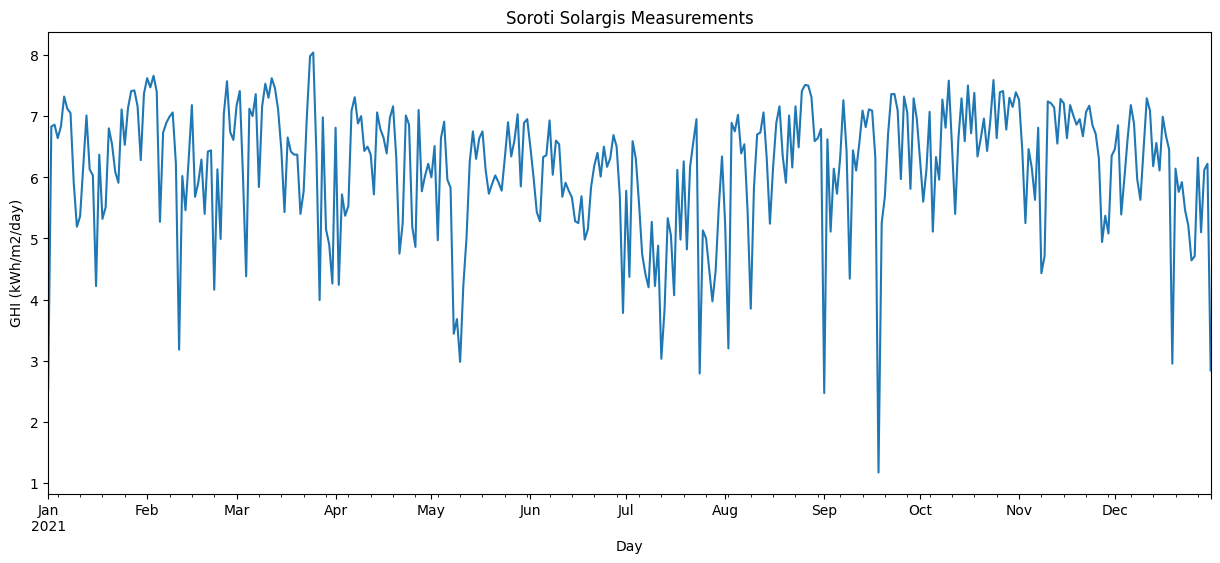

In [5]:
plt.figure(figsize=(15, 6))
ghi_solargis = Soroti_ground['GHI_SAT (kWh/m2/day)']
ghi_solargis.plot()
plt.ylabel('GHI (kWh/m2/day)')
plt.title('Soroti Solargis Measurements')
plt.show()

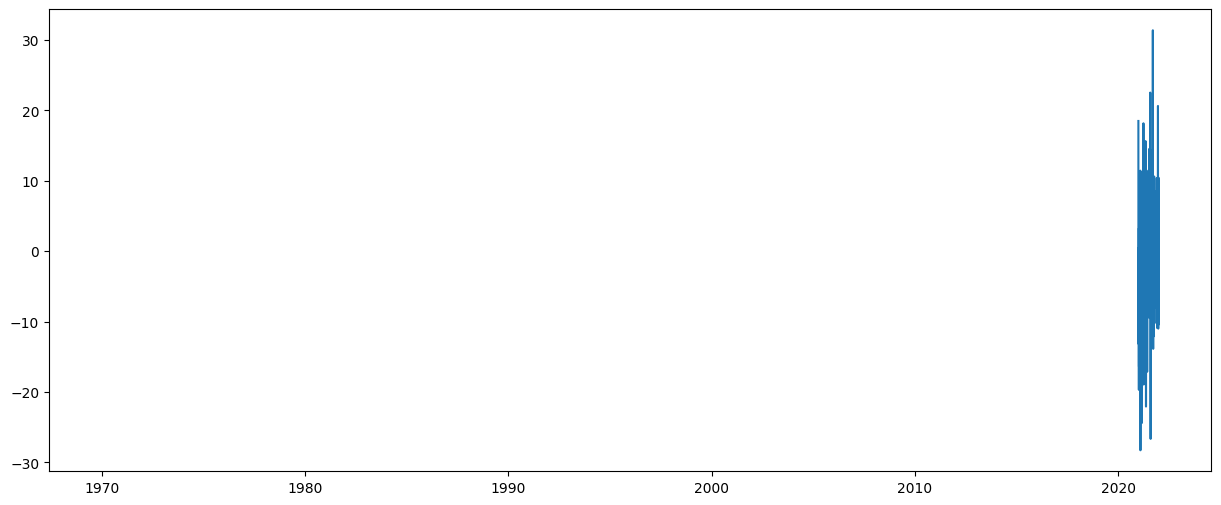

In [10]:
plt.figure(figsize=(15, 6))
diff = Soroti_ground['GHI (1) vs (SAT) (%)']
rRMSD = StatisticalMetrics.relative_rmsd(ghi_ground, ghi_solargis)
plt.plot(diff, label= 'percentage difference')
plt.plot(rRMSD, label= 'rRMSD')


# Clearsky radiation

In [54]:
soroti = pvlib.location.Location(latitude, longitude, tz=tz)
times = pd.date_range(start, end, freq='1h', tz=tz)
times_utc = times.tz_convert('UTC')

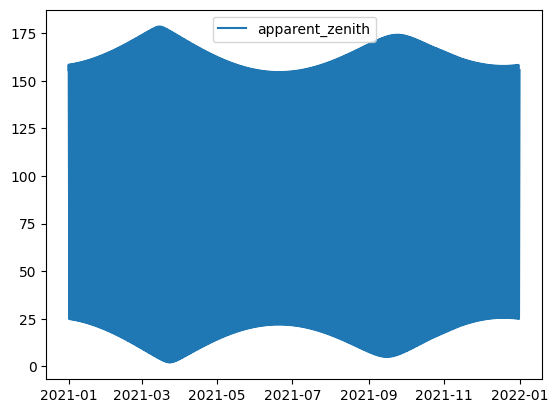

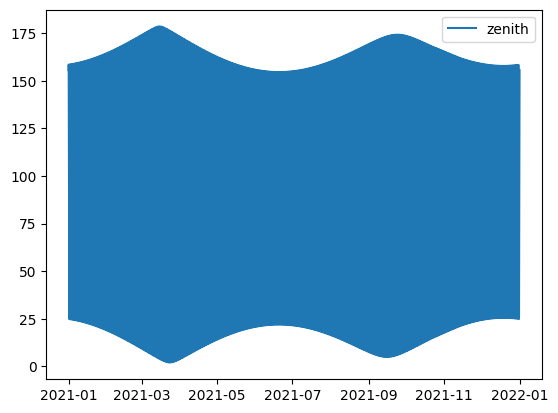

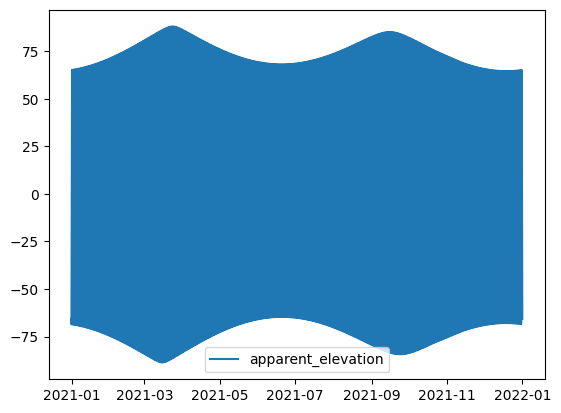

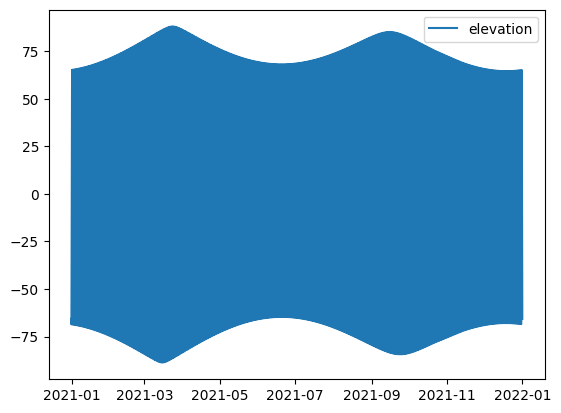

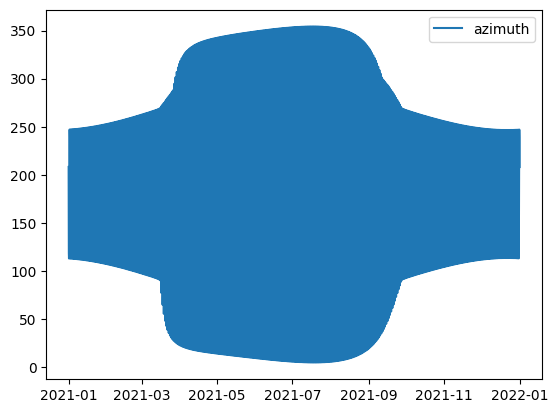

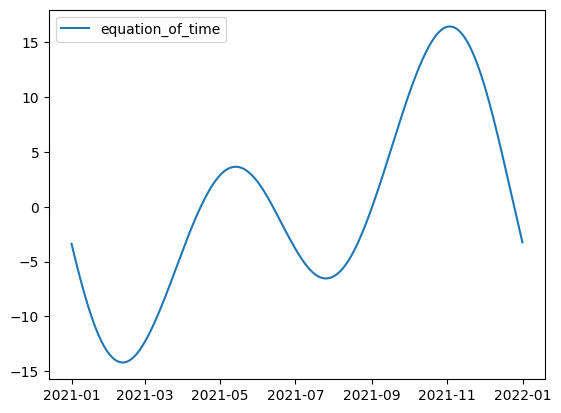

In [60]:
ext_irrad = soroti.get_solarposition(times)
# loop to plot each parameeter in ext_irrad in a separate plot using sub plots
for i in ext_irrad:
    plt.plot(times_utc, ext_irrad[i], label=i)
    plt.legend()
    plt.show()
    plt.close()

<Axes: >

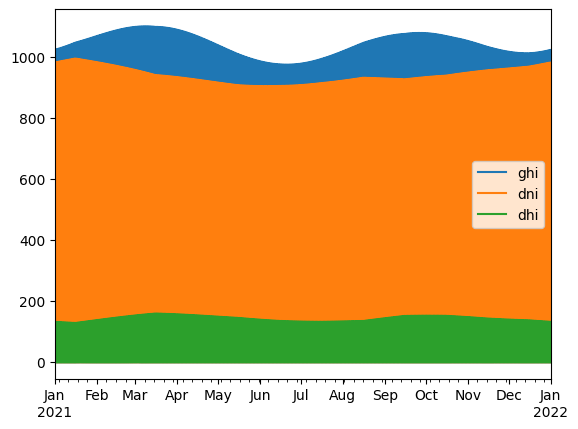

In [56]:
clsky_irrad = soroti.get_clearsky(times)
clsky_irrad.plot()

# Diffuse

<Axes: >

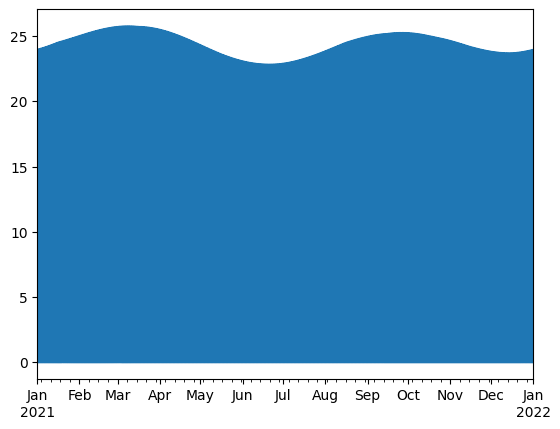

In [49]:
ground_irrad = pvlib.irradiance.get_ground_diffuse(40, clsky_irrad['ghi'], albedo=0.2)
ground_irrad.plot()

/home/mukiibirogers/GitHub/Solar_irradiation/.susse_venv/lib64/python3.12/site-packages/pvlib/irradiance.py:26: pvlibDeprecationWarning: SURFACE_ALBEDOS has been moved to the albedo module as of v0.11.0. Please use pvlib.albedo.SURFACE_ALBEDOS.
  warnings.warn(f"{attr} has been moved to the albedo module as of "


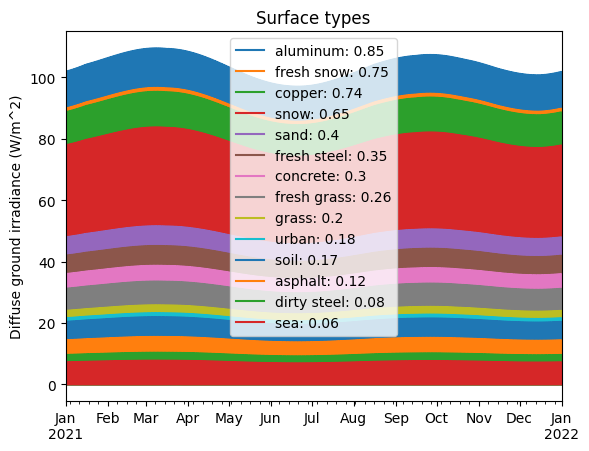

In [62]:
for surface, albedo in sorted(pvlib.irradiance.SURFACE_ALBEDOS.items(), key=lambda x: x[1], reverse=True):
    ground_irrad = pvlib.irradiance.get_ground_diffuse(40, clsky_irrad['ghi'], surface_type=surface)
    ground_irrad.plot(label='{}: {}'.format(surface, albedo))

plt.legend()
plt.ylabel('Diffuse ground irradiance (W/m^2)')
plt.title('Surface types');